# Descripción del conjunto de datos

Este conjunto de datos contiene información académica y demográfica de estudiantes, incluyendo hábitos de estudio, contexto familiar y desempeño académico.

El conjunto de datos fue obtenido de Kaggle y puede consultarse en el siguiente enlace:
https://www.kaggle.com/datasets/devansodariya/student-performance-data

Cada fila representa a un estudiante y cada columna describe características que pueden influir en su rendimiento académico.

# Definición del problema

El objetivo de este análisis es predecir el rendimiento académico de un estudiante a partir de variables demográficas y académicas.

Dado que la variable objetivo representa una puntuación numérica, el problema se formula como un problema de regresión.

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df = pd.read_csv('data/student_data.csv')
df.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [7]:
df.info()
df.describe().T


<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

,count,mean,std,min,25%,50%,75%,max
age,395.0,16.696203,1.276043,15.0,16.0,17.0,18.0,22.0
Medu,395.0,2.749367,1.094735,0.0,2.0,3.0,4.0,4.0
Fedu,395.0,2.521519,1.088201,0.0,2.0,2.0,3.0,4.0
traveltime,395.0,1.448101,0.697505,1.0,1.0,1.0,2.0,4.0
studytime,395.0,2.035443,0.839240,1.0,1.0,2.0,2.0,4.0
failures,395.0,0.334177,0.743651,0.0,0.0,0.0,0.0,3.0
famrel,395.0,3.944304,0.896659,1.0,4.0,4.0,5.0,5.0
freetime,395.0,3.235443,0.998862,1.0,3.0,3.0,4.0,5.0
goout,395.0,3.108861,1.113278,1.0,2.0,3.0,4.0,5.0
Dalc,395.0,1.481013,0.890741,1.0,1.0,1.0,2.0,5.0


In [9]:
# Identify numeric and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()


target = 'G3'

# Remove target from numerical features
if target in numerical_cols:
    numerical_cols.remove(target)

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)
print("Target:", target)


Numerical columns: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']
Categorical columns: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
Target: G3


## Selección de variables para el modelo

- Variable objetivo (target): `G3` (calificación final).
- Variables de entrada (features): todas las columnas numéricas excepto `G3`, y todas las columnas categóricas.


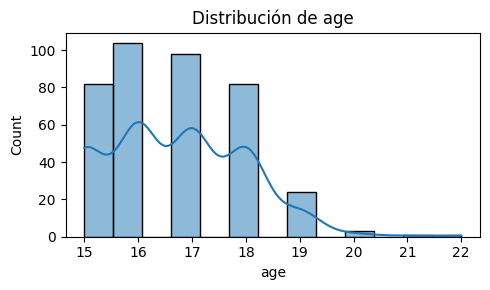

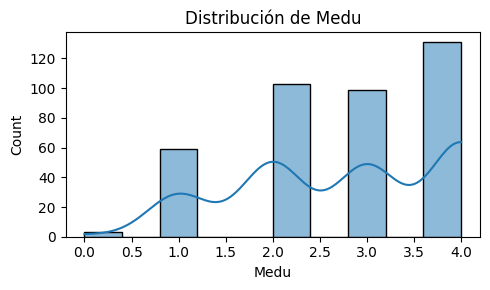

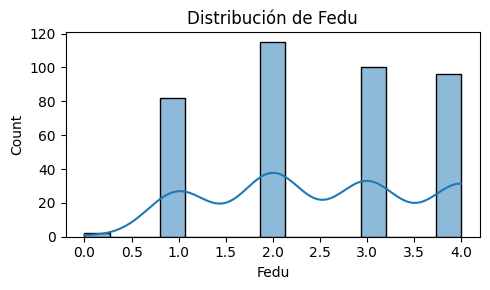

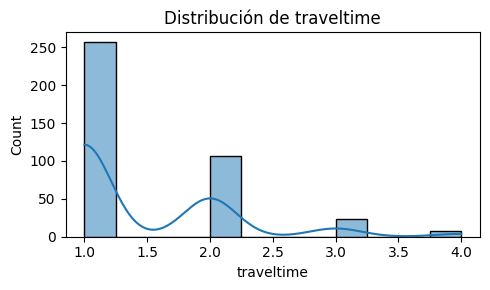

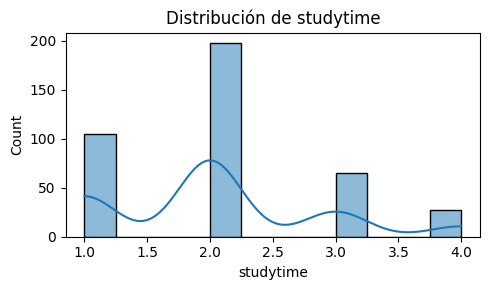

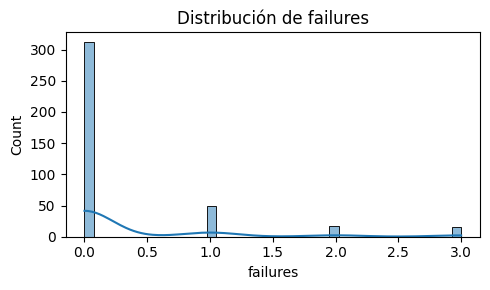

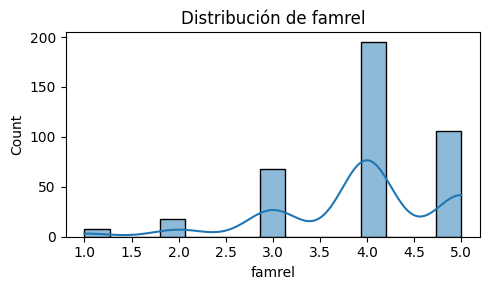

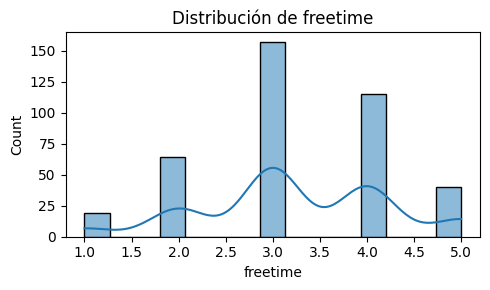

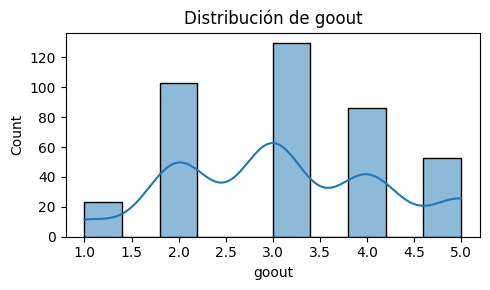

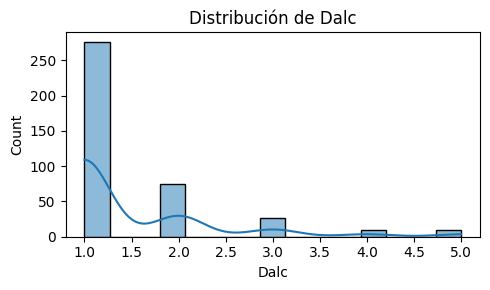

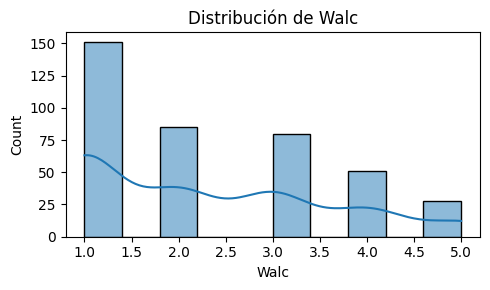

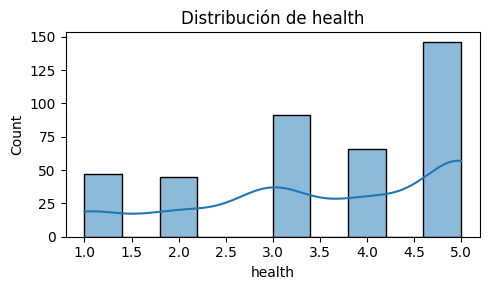

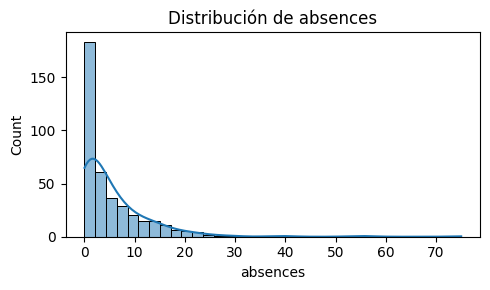

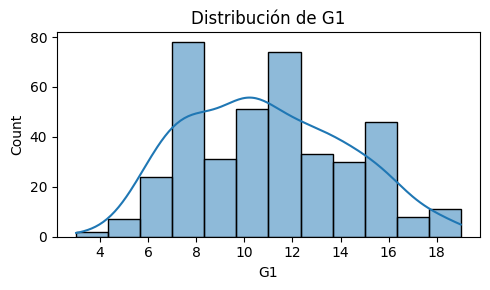

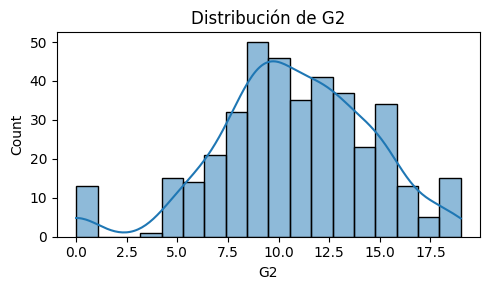

In [10]:
for col in numerical_cols:
    plt.figure(figsize=(5, 3))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribución de {col}')
    plt.tight_layout()
    plt.show()


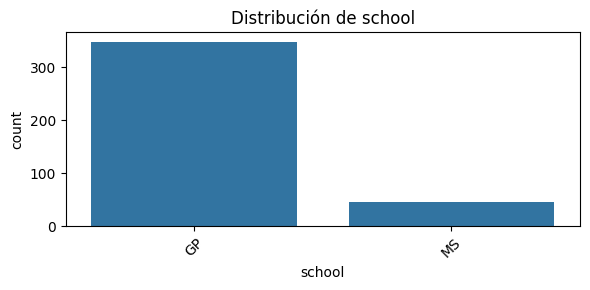

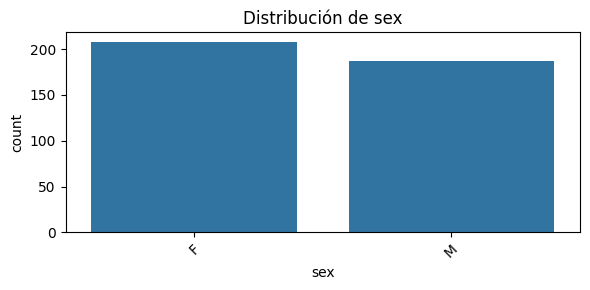

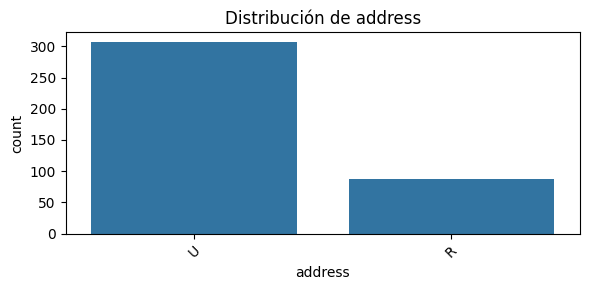

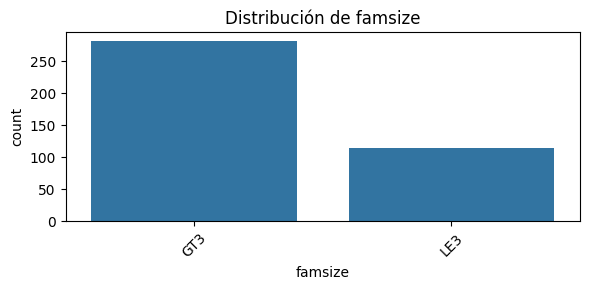

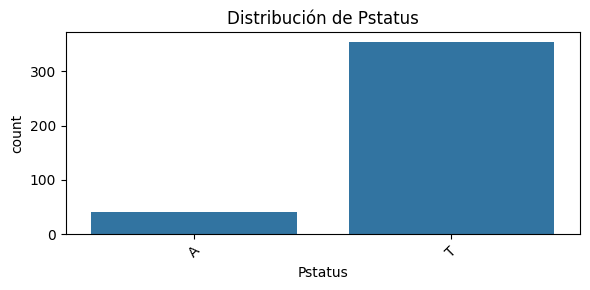

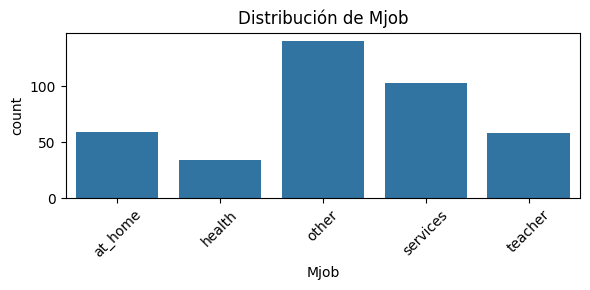

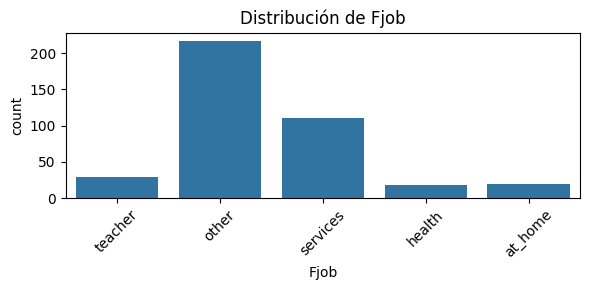

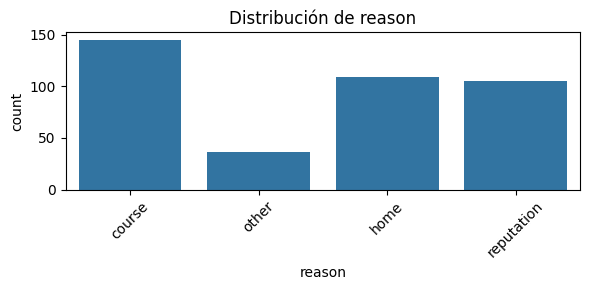

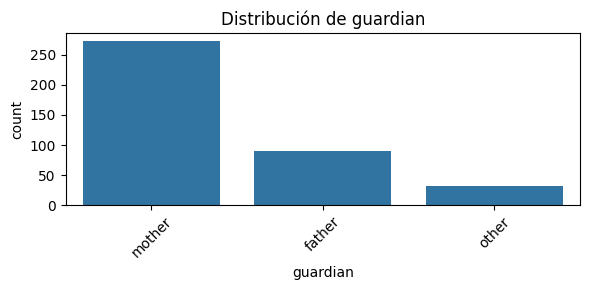

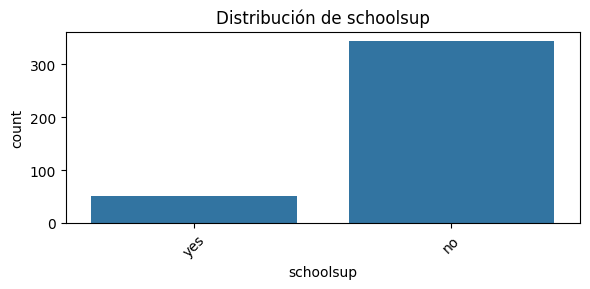

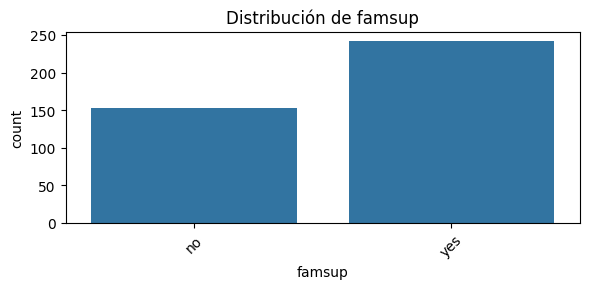

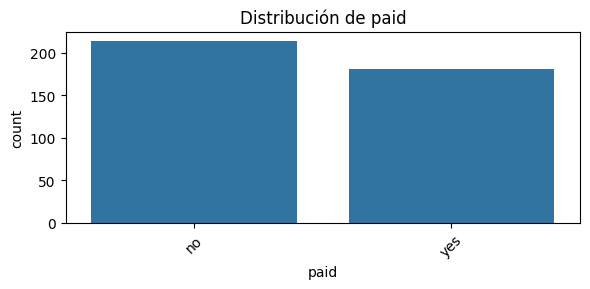

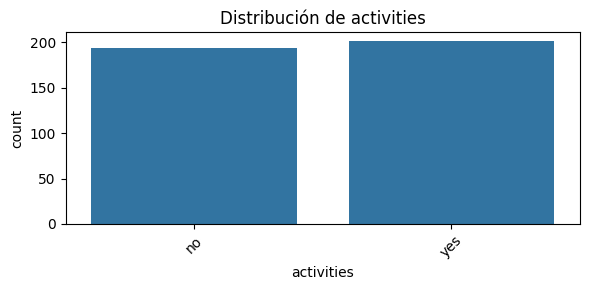

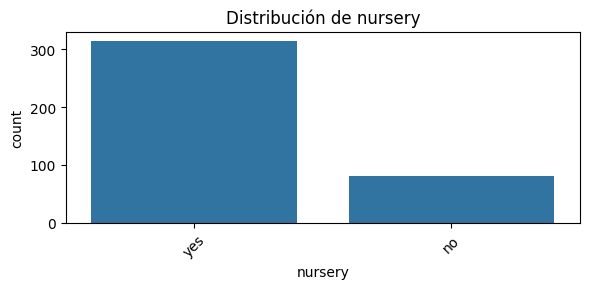

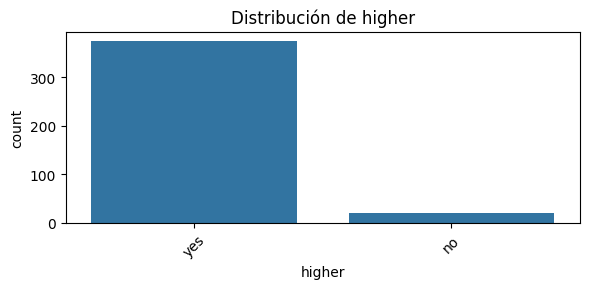

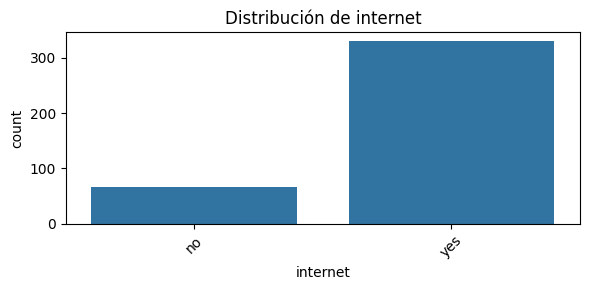

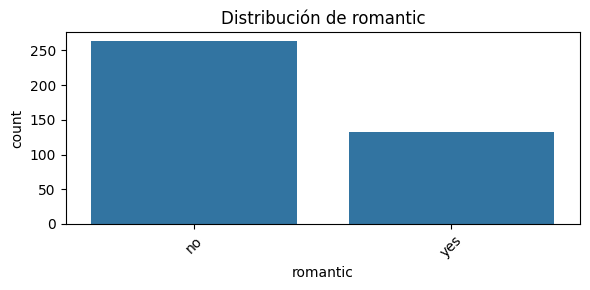

In [11]:
for col in categorical_cols:
    plt.figure(figsize=(6, 3))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribución de {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [16]:
missing_counts = df.isnull().sum()
missing_counts[missing_counts > 0]
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_percent[missing_percent > 0]


Series([], dtype: float64)

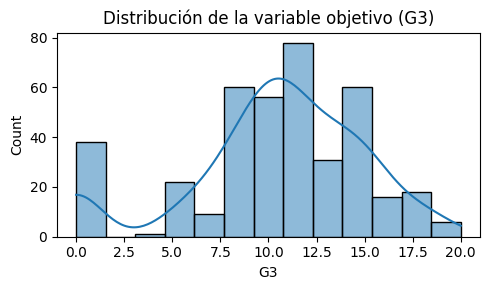

In [18]:
plt.figure(figsize=(5, 3))
sns.histplot(df[target], kde=True)
plt.title('Distribución de la variable objetivo (G3)')
plt.tight_layout()
plt.show()


## Hallazgos principales del EDA

Se identificaron variables numéricas y categóricas. Las variables numéricas presentan diferentes escalas y algunas distribuciones sesgadas (por ejemplo, `absences`), lo que sugiere la necesidad de aplicar escalamiento en el preprocesamiento.

No se detectaron valores faltantes en el conjunto de datos, por lo que no será necesario aplicar imputación por valores nulos.

Se selecciona `G3` como variable objetivo, ya que representa la calificación final del estudiante. Variables como `G1` y `G2` corresponden a calificaciones previas y podrían ser predictoras relevantes para `G3`.


## Pipeline de preprocesamiento

Se aplican transformaciones distintas según el tipo de variable:

- Variables numéricas (`age`, `Medu`, `Fedu`, `studytime`, `absences`, `G1`, `G2`, etc.):
  - `SimpleImputer(strategy="mean")`: aunque el dataset no presenta valores faltantes, se incluye para robustez ante datos futuros o cambios en el dataset.
  - `StandardScaler()`: las variables numéricas tienen escalas diferentes, por lo que se estandarizan para beneficiar el entrenamiento del modelo.

- Variables categóricas (`school`, `sex`, `address`, `Mjob`, `Fjob`, etc.):
  - `SimpleImputer(strategy="most_frequent")`: se incluye por robustez ante valores faltantes en datos nuevos.
  - `OneHotEncoder(handle_unknown="ignore")`: convierte categorías a variables binarias y evita errores si aparecen categorías nuevas en el conjunto de prueba.


In [25]:
preprocessing = ColumnTransformer(
    transformers=[
        ('num', make_pipeline(
            SimpleImputer(strategy='mean'),
            StandardScaler()
        ), numerical_cols),
        ('cat', make_pipeline(
            SimpleImputer(strategy='most_frequent'),
            OneHotEncoder(handle_unknown='ignore')
        ), categorical_cols),
    ]
)
X = df[numerical_cols + categorical_cols]
y = df['G3']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = make_pipeline(
    preprocessing,
    LinearRegression()
)

model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different

In [26]:
y_pred = model.predict(X_test)
y_pred[:10]


array([ 6.00160699, 11.52847844,  2.86643677,  8.79663116,  8.55310627,
       11.88964112, 19.09674195,  7.17307901,  7.4050707 , 12.31153657])